In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from asrl.ogmapping.og_map import OccupancyGridMapper, log_odds_to_entropy
import matplotlib.pyplot as plt
from time import perf_counter
from spatialmath.base import *
import scipy
from asrl.ogmapping.utils import transform_points

In [2]:
from asrl.slam_sim.array_map import ArrayMap

env = ArrayMap('/home/dev/workspace/asrl/maps/floorplan1.txt', resolution=1.0, verbose=True)
height, width = env._walls.shape

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Walls shape: (15, 20), Free space shape: (15, 20)
[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 1 1 1 1 0 0 1 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 1]
 [1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]
 [1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]


In [3]:
scan_positions_xy_m = env._free_space_xy_m
n_poses = scan_positions_xy_m.shape[0]

poses = np.zeros((n_poses, 3))
poses[:, :2] = scan_positions_xy_m
poses[:, 2] = np.random.uniform(0, 2 * np.pi, n_poses)

scans.shape = (30780, 2)


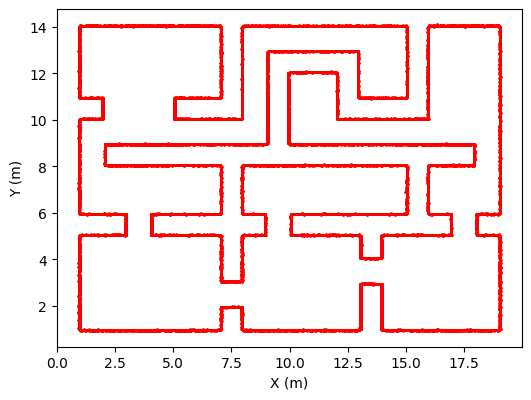

In [4]:
scans_B_BP_2d, n_rays = env.raycast_in_map(poses, range_noise_m=0.01)

W_T_B = np.stack([xyt2tr(p) for p in poses], axis=0)
scans_W_WP_2d = transform_points(W_T_B, scans_B_BP_2d)
scans_W_WP_2d = np.reshape(scans_W_WP_2d, (n_poses * n_rays, 2))

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

print(f"scans.shape = {scans_W_WP_2d.shape}")

ax.scatter(scans_W_WP_2d[:, 0], scans_W_WP_2d[:, 1], c='red', s=1)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_aspect('equal')
plt.show()

In [5]:
og_map = OccupancyGridMapper(
    0.2,
    width,
    height,
    p_hit=0.7, p_miss=0.3)

og_map.process_scans(
    poses,
    scans_B_BP_2d,
    n_rays
)

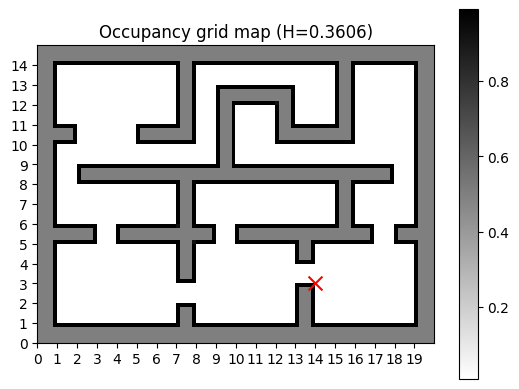

In [6]:
grid_prob = og_map.to_prob_map()

extent = [0, og_map.width_m, 0, og_map.height_m]

plt.figure()
grid_prob_img = plt.imshow(grid_prob, 
                           cmap='gray_r', interpolation='nearest',
                           origin='upper', extent=extent)

plt.scatter([14.0], [3.0], c='red', s=100, marker='x')

xticks = np.arange(0, og_map.width_m, 1.0)
yticks = np.arange(0, og_map.height_m, 1.0)
plt.xticks(xticks)
plt.yticks(yticks)

# plt.grid(which='both', color='white', linestyle='--', linewidth=0.5)
plt.colorbar(grid_prob_img)
plt.title(f'Occupancy grid map (H={og_map.entropy:.4f})')
plt.show()

og_map.reset()

In [7]:
%%timeit

scans, n_rays = env.raycast_in_map(poses, range_noise_m=0.01)
og_map.process_scans(
    poses,
    scans,
    n_rays
)

19 ms ± 683 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [16]:
%%timeit
og_map.entropy

73 μs ± 8.74 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [11]:
%%timeit
og_map.to_prob_map()

17.7 μs ± 678 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
